# Example for proton dose calculation using pencilbeam engine.

This example demonstrates how to use the pyRadPlan library to perform proton dose calculations.

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/pencilbeam_proton.py

In [1]:
# Import necessary libraries
import logging

import numpy as np

from pyRadPlan import (
    IonPlan,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    load_tg119,
    plot_slice,
    settings,
)
from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE
from pyRadPlan.optimization.objectives import SquaredDeviation, SquaredOverdosing, MeanDose


settings.xp.prefer_gpu = True
settings.xp.preferred_cpu_array_backend = "numpy"
logging.basicConfig(level=logging.INFO)

D:\Python\pyRadPlan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load TG119 (provided within pyRadPlan)
ct, cst = load_tg119()

In this section, we create a proton therapy plan using the ParticleHongPencilBeamEngine.

In [3]:
# Create a plan object
pln = IonPlan(radiation_mode="protons", machine="Generic")
# "display" and "max_iter" are optional; left out, the solver's own defaults apply.
# See the "Solver configuration and optimization utilities" tutorial for the full set.
pln.prop_opt = {
    "solver": "scipy",  # or "ipopt", the default
    "display": True,
    "max_iter": 500,
}
pln.prop_dose_calc = {"dose_grid": ct.grid}

# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

# Optimization
cst.vois[0].objectives = [SquaredOverdosing(priority=10.0, d_max=1.0)]  # OAR
cst.vois[1].objectives = [SquaredDeviation(priority=100.0, d_ref=3.0)]  # Target
cst.vois[2].objectives = [
    MeanDose(priority=1.0, d_ref=0.0),
    SquaredOverdosing(priority=10.0, d_max=2.0),
]  # BODY

# Calculate optimized fluence
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Compute the result on the CT grid
result = dij.compute_result_ct_grid(fluence)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

Beam: 100%|██████████| 1/1 [00:00<00:00,  1.20b/s]

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (167,167,129) with resolution x=3.000000, y=3.000000, z=2.500000.


INFO:pyRadPlan.dose.engines._base_pencilbeam_particle:Using a single Gaussian pencil-beam kernel model!



...

INFO:pyRadPlan.optimization.solvers._scipy_solver:Iteration 169: objective = 3.299313e-01


INFO:pyRadPlan.optimization.solvers._scipy_solver:SciPy finished: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


INFO:pyRadPlan.optimization.problems._nonlin_fluence:172 Objective function evaluations, avg. time: 0.00683825 +/- 0.0154348 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:172 Derivative evaluations, avg. time: 0.00792921 +/- 0.00516895 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 2.91306 s


Visualize the results

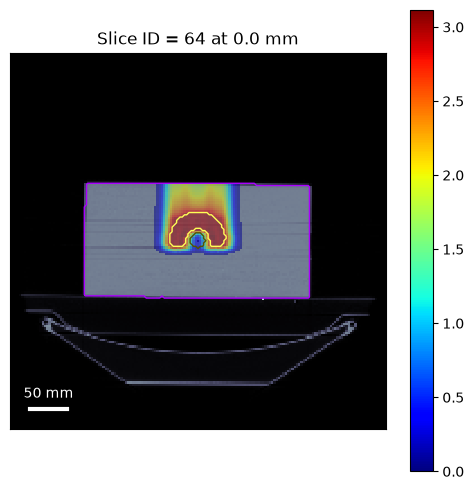

In [4]:

if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result)
else:
    # Choose a slice to visualize
    view_slice = int(np.round(ct.size[2] / 2))
    plot_slice(ct, cst, result["physical_dose"], view_slice)